In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, silhouette_score

In [2]:
df = pd.read_csv("./energy_efficiency.csv")

## 1. Understanding the dataset

In [3]:
df.shape

(768, 10)

In [4]:
df.columns

Index(['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
       'Overall_Height', 'Orientation', 'Glazing_Area',
       'Glazing_Area_Distribution', 'Heating_Load', 'Cooling_Load'],
      dtype='str')

In [5]:
df.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [6]:
df.isnull().sum()

Relative_Compactness         0
Surface_Area                 0
Wall_Area                    0
Roof_Area                    0
Overall_Height               0
Orientation                  0
Glazing_Area                 0
Glazing_Area_Distribution    0
Heating_Load                 0
Cooling_Load                 0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Relative_Compactness       768 non-null    float64
 1   Surface_Area               768 non-null    float64
 2   Wall_Area                  768 non-null    float64
 3   Roof_Area                  768 non-null    float64
 4   Overall_Height             768 non-null    float64
 5   Orientation                768 non-null    int64  
 6   Glazing_Area               768 non-null    float64
 7   Glazing_Area_Distribution  768 non-null    int64  
 8   Heating_Load               768 non-null    float64
 9   Cooling_Load               768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [9]:
df.describe()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307195,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090204,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


## 2. Outlier analysis

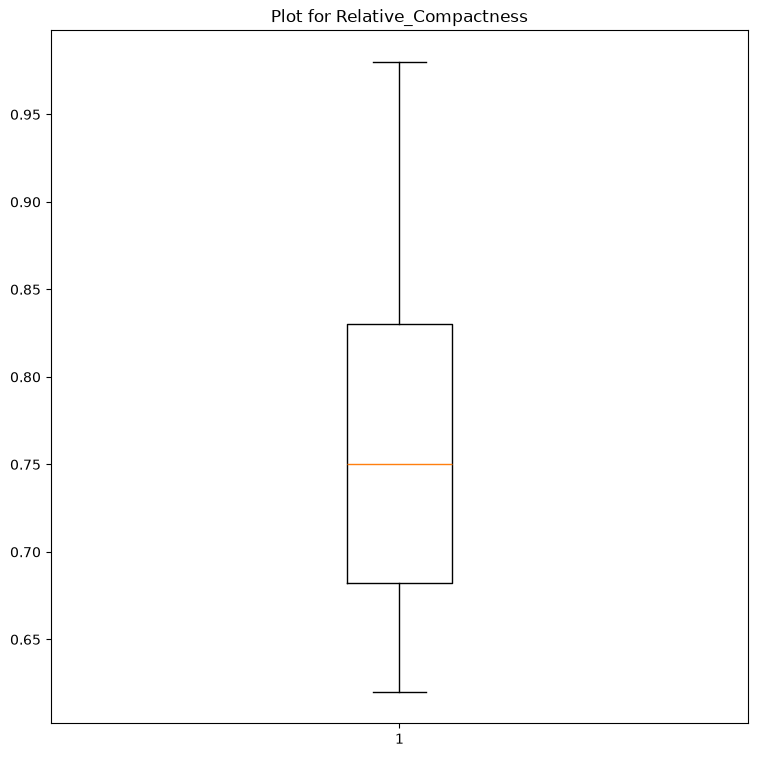

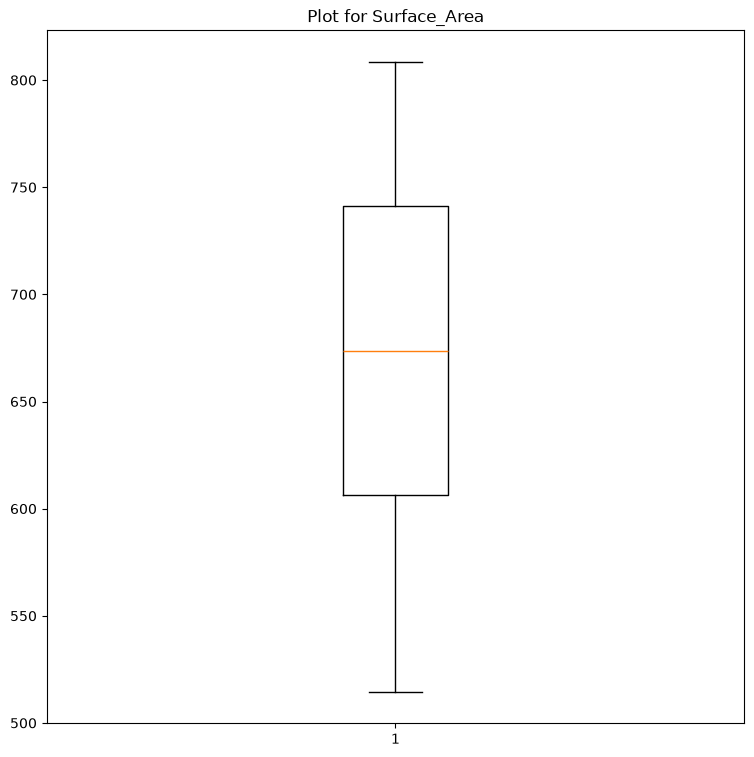

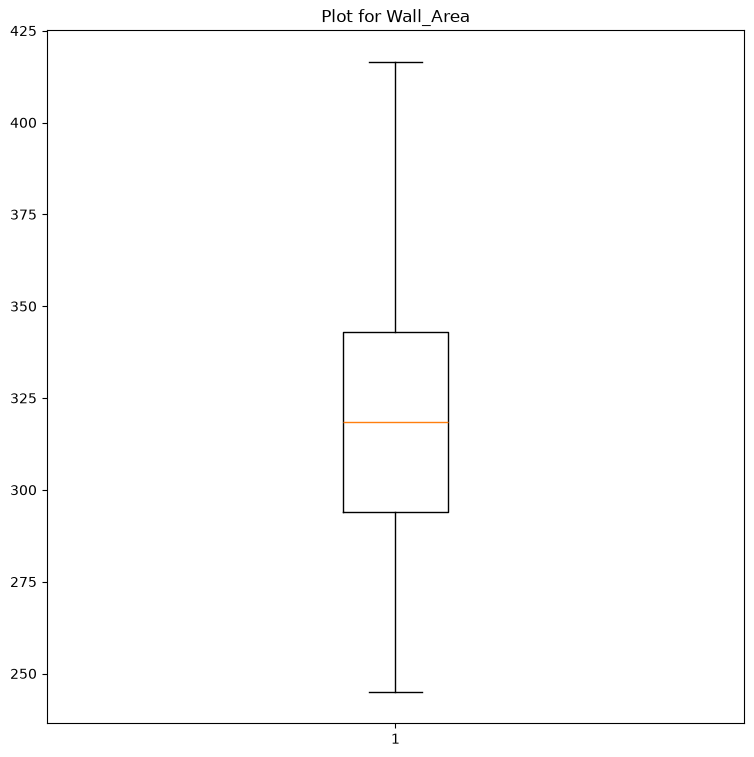

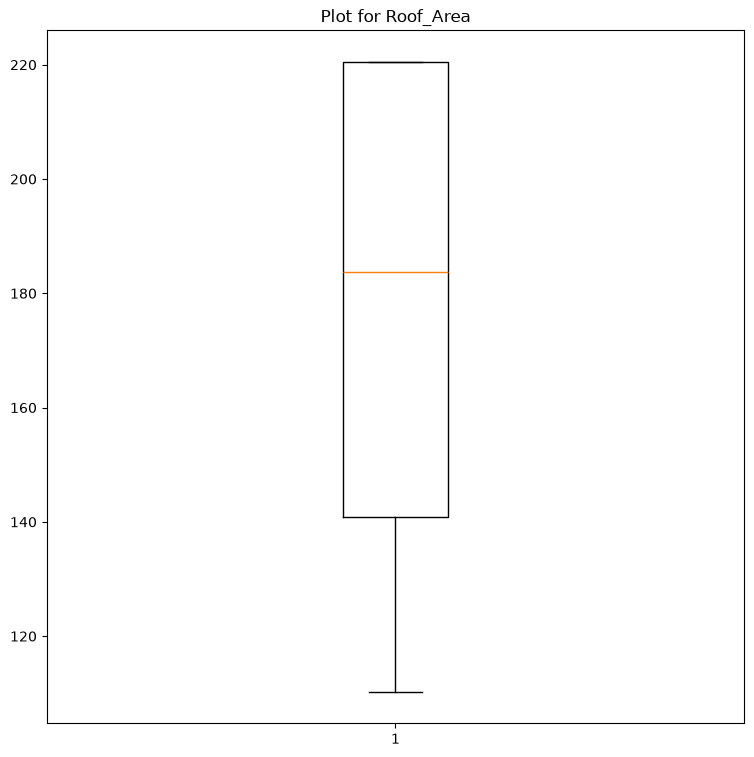

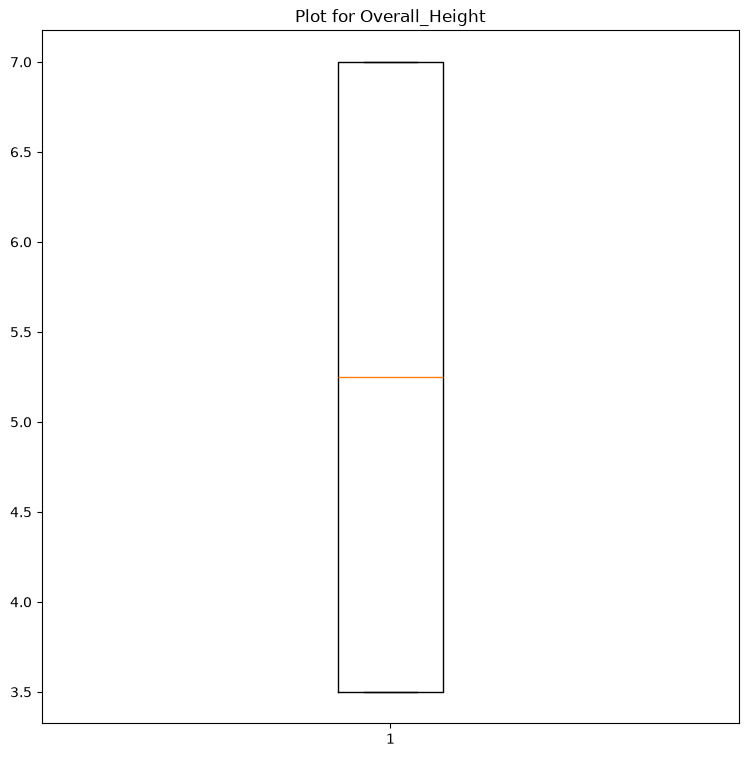

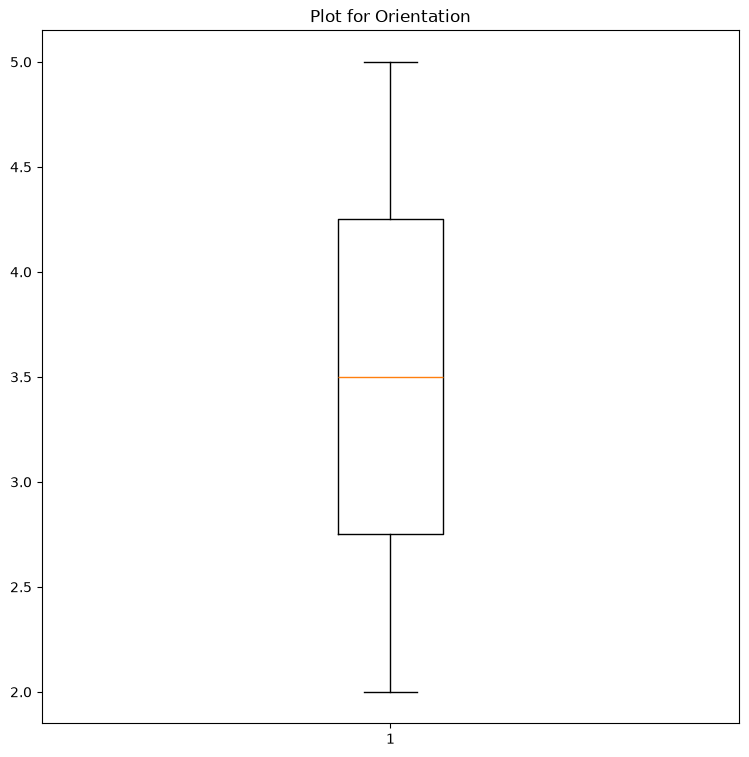

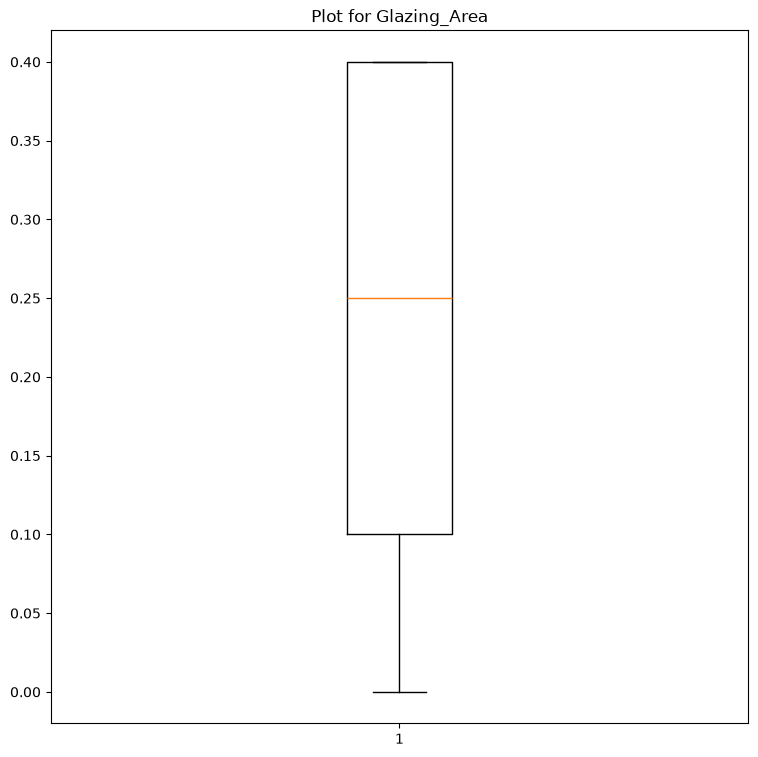

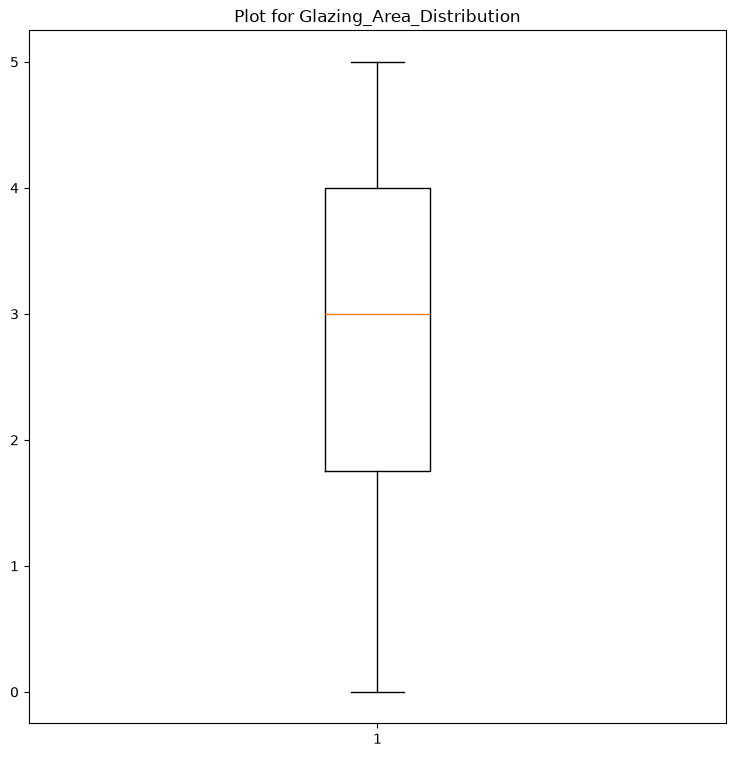

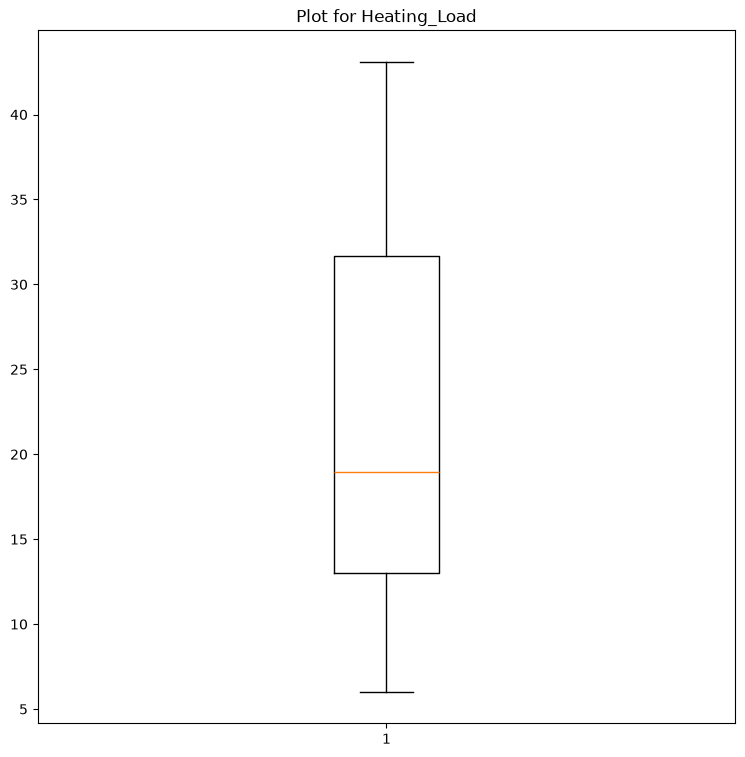

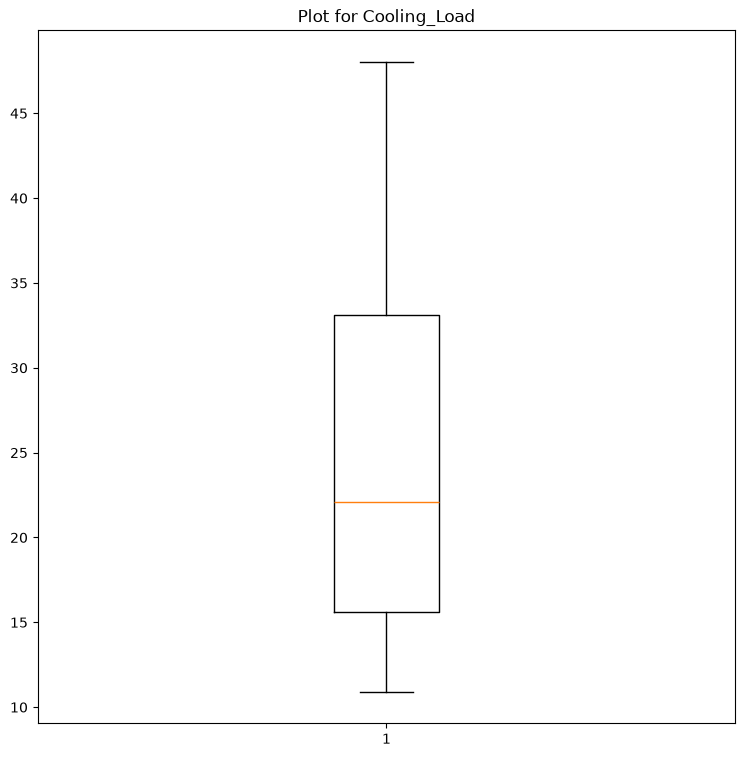

In [10]:
for col in df.columns:
    plt.figure(figsize=(9,9))
    plt.boxplot(x=df[col])
    plt.title(f"Plot for {col}")
    plt.show()

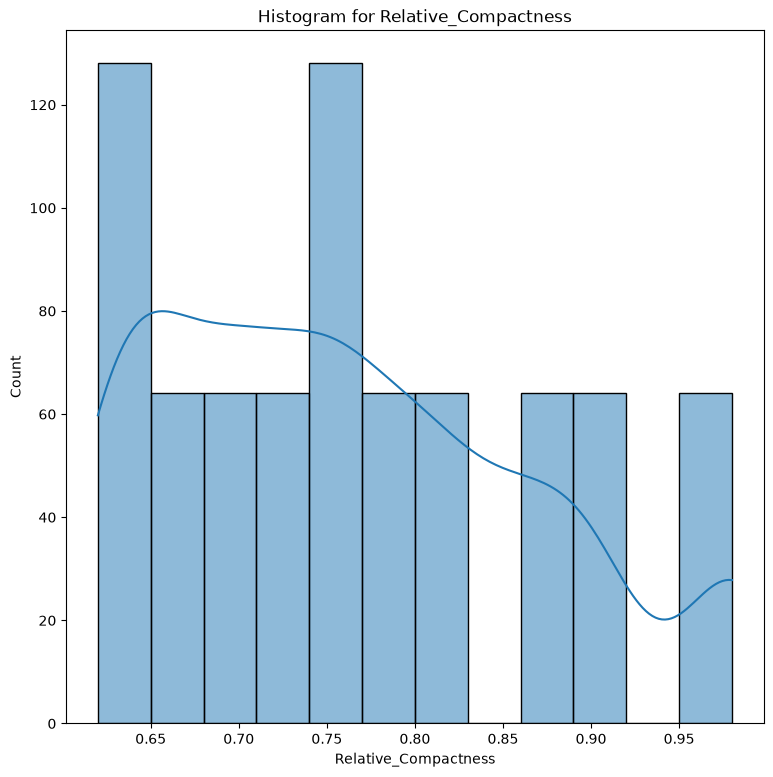

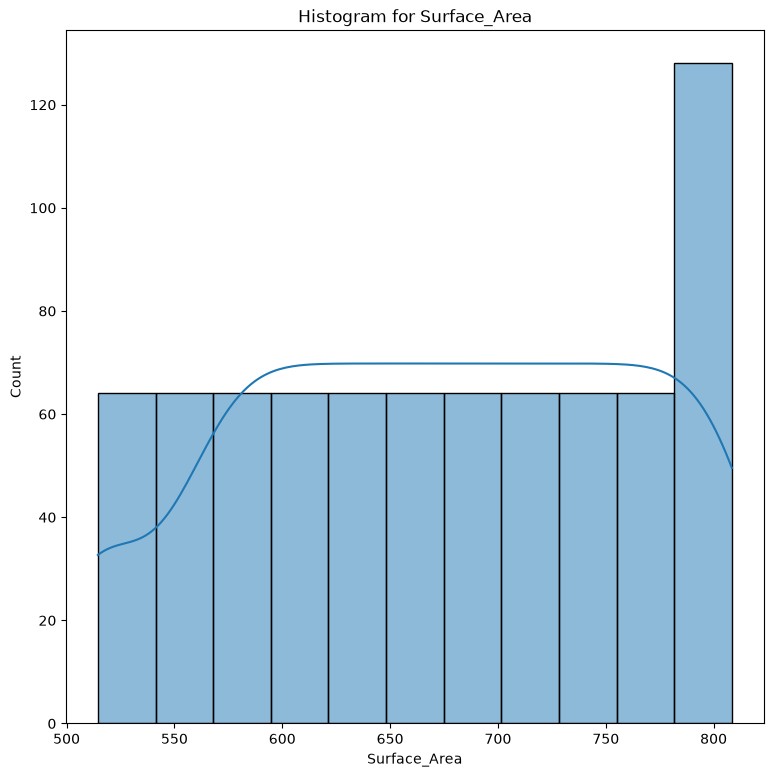

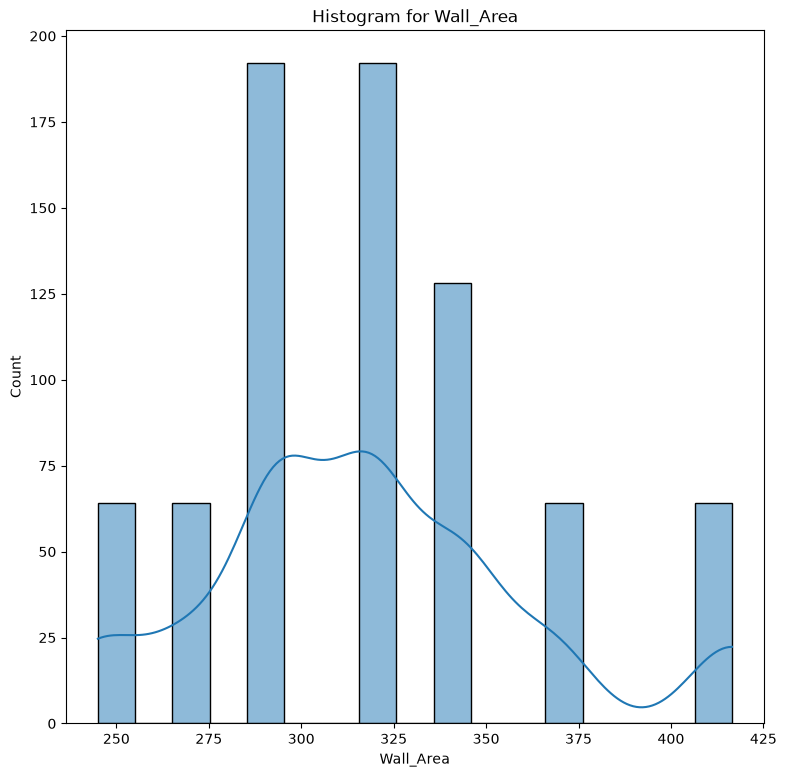

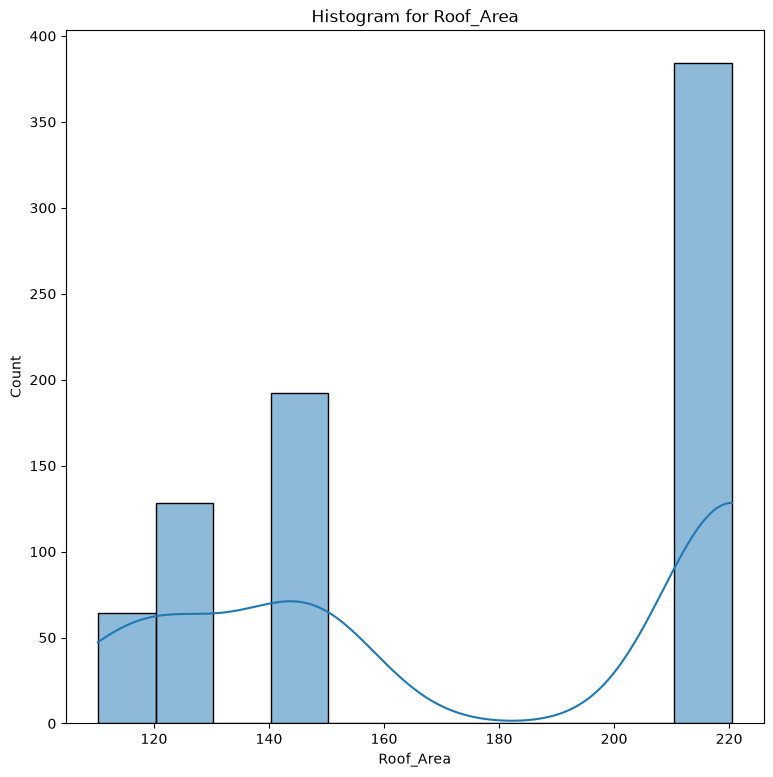

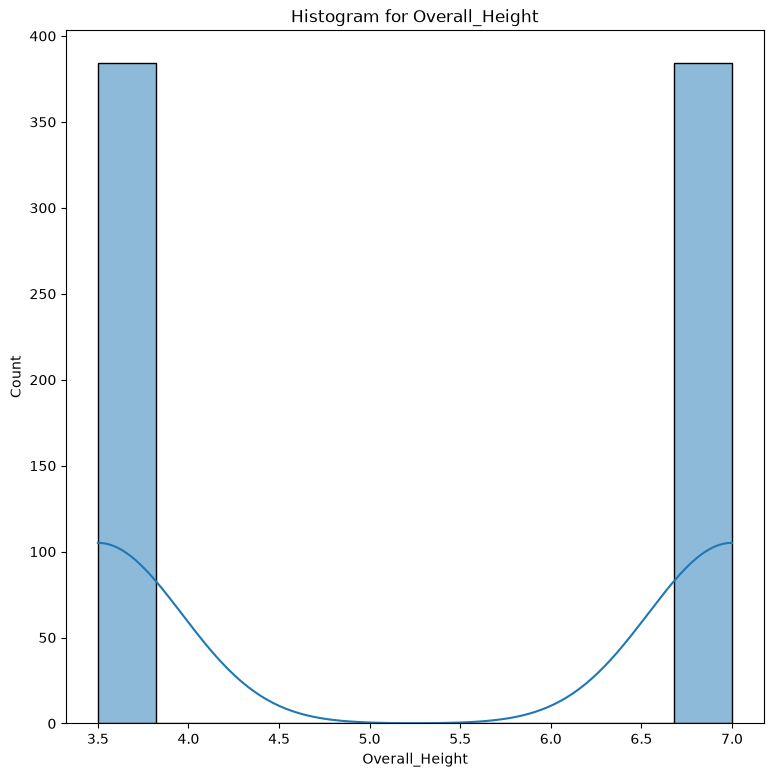

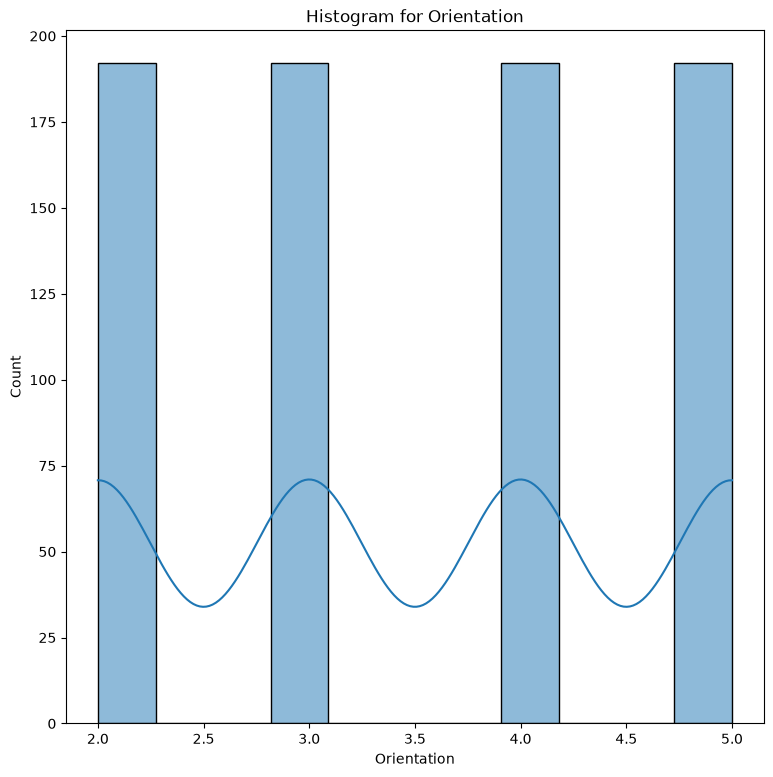

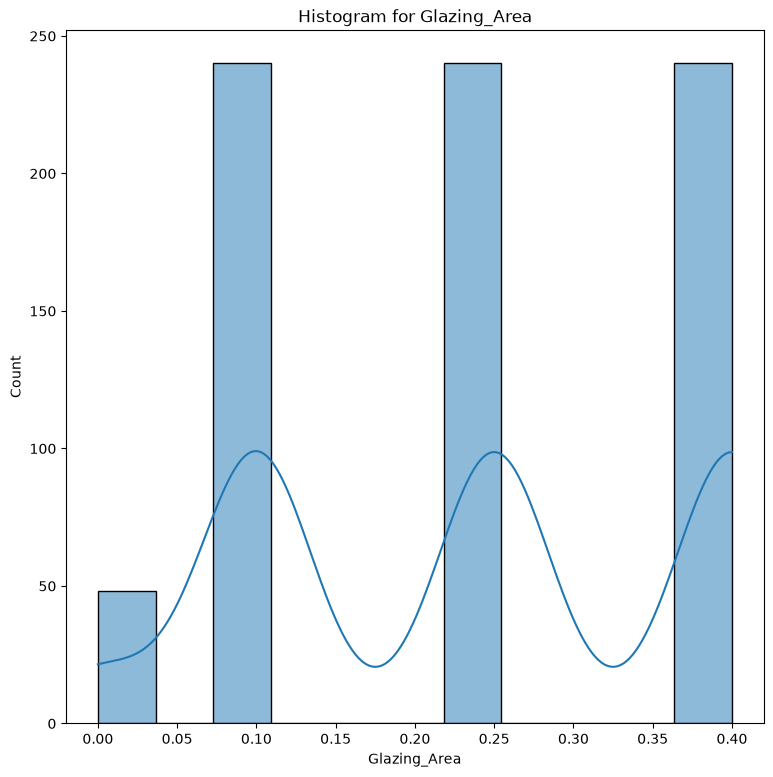

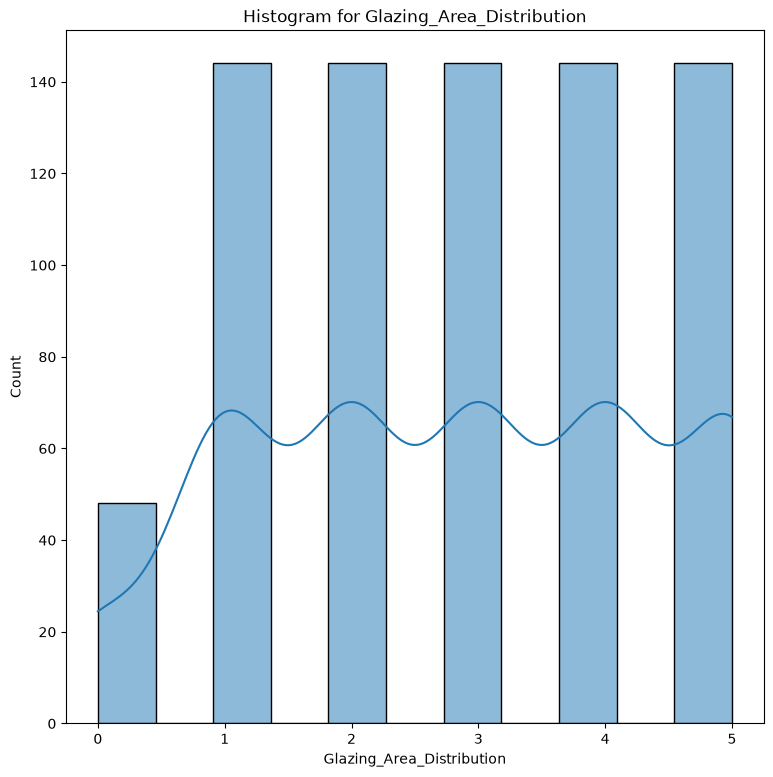

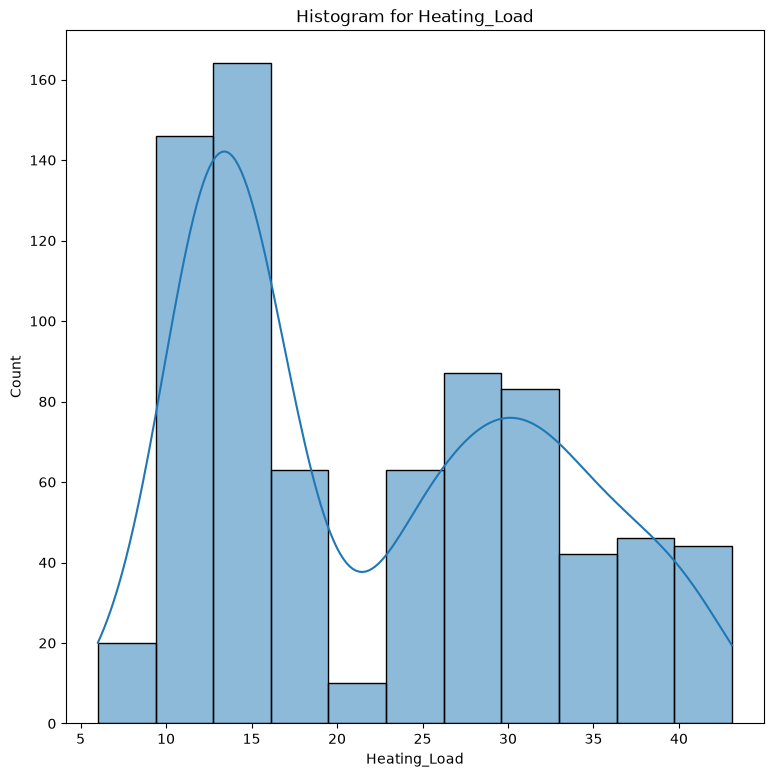

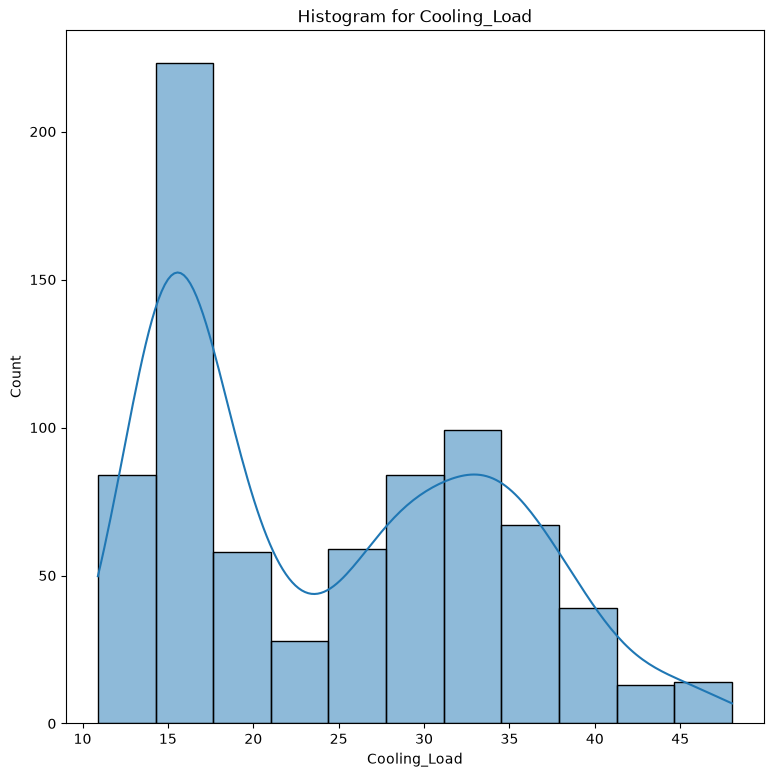

In [11]:
for col in df.columns:
    plt.figure(figsize=(9,9))
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram for {col}")
    plt.show()

## 3. Correlation analysis

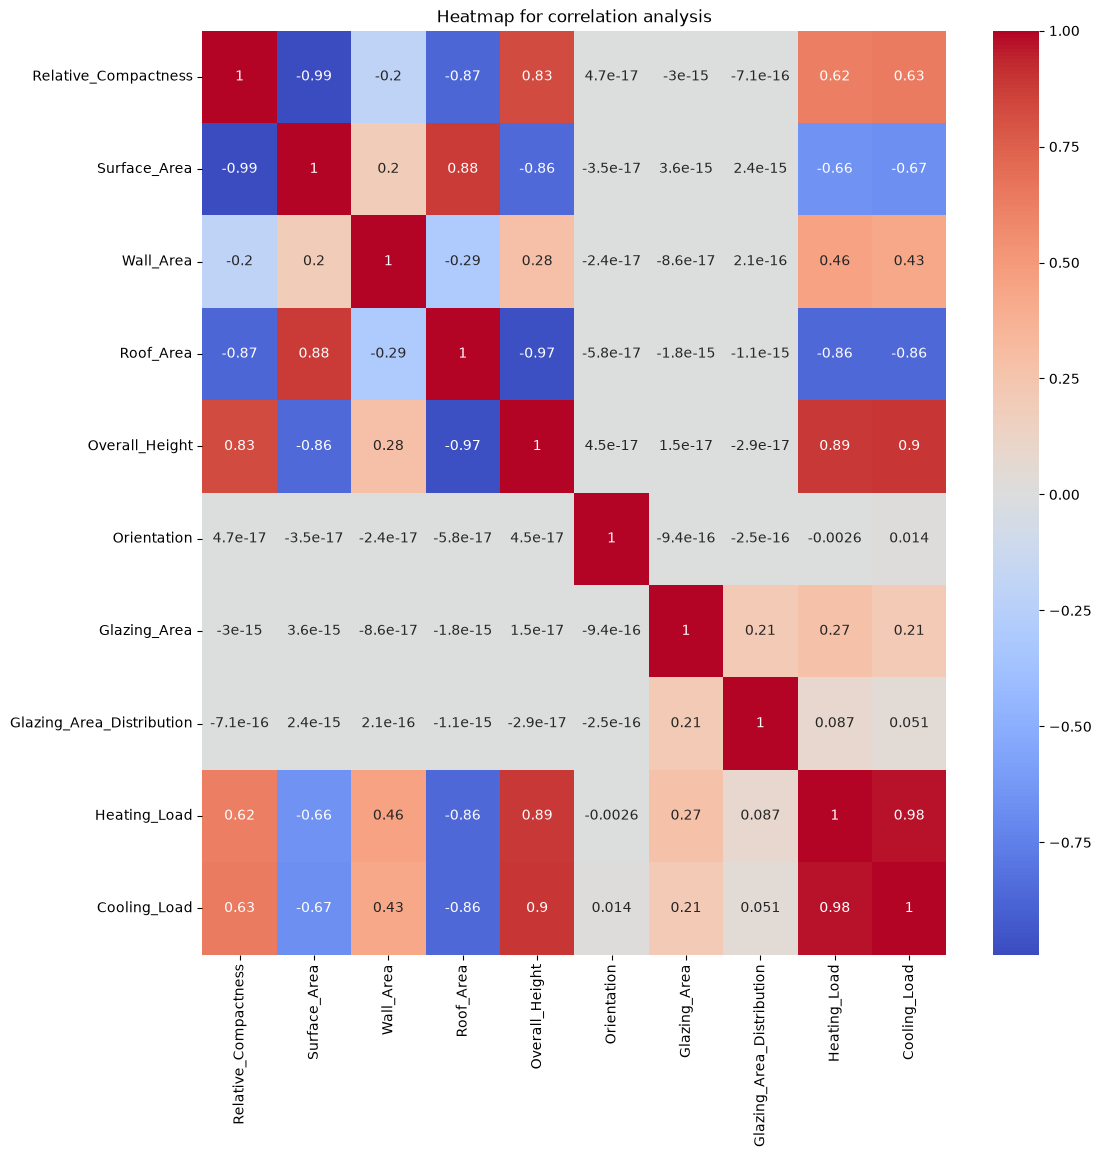

In [12]:
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(12,12))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Heatmap for correlation analysis")
plt.show()

## 4. Preparing the data for model

In [13]:
dfcopy = df.copy()

In [14]:
dfcopy.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [15]:
cooling_median = dfcopy["Cooling_Load"].median()

dfcopy["High_Cooling_Load"] = (dfcopy["Cooling_Load"] > cooling_median).astype(int)

classification_df = dfcopy.drop(columns=["Cooling_Load", "Heating_Load"], errors='ignore')

In [16]:
classification_df.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,High_Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,0
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,0
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,0
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,0
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,1


splitting the training and testing data

In [17]:
X = classification_df.drop("High_Cooling_Load", axis=1)
y = classification_df["High_Cooling_Load"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [19]:
model = RandomForestClassifier(
    n_estimators=600,
    random_state=42,
    class_weight='balanced',
    bootstrap=True,
    max_depth=8,
    min_samples_leaf=4,
    min_samples_split=12,
    max_features='sqrt'
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",600
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",12
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 

In [20]:
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy score: ", accuracy_score(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_pred_prob)
print("\n ROC AUC score: ", roc_auc)

cm = confusion_matrix(y_test, y_pred)
print("\n Confusion matrix: \n", cm)

print("\n Classification report: \n ", classification_report(y_test, y_pred))

Accuracy score:  0.9805194805194806

 ROC AUC score:  0.9994909214322076

 Confusion matrix: 
 [[70  1]
 [ 2 81]]

 Classification report: 
                precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.99      0.98      0.98        83

    accuracy                           0.98       154
   macro avg       0.98      0.98      0.98       154
weighted avg       0.98      0.98      0.98       154



## 5. Inference form model

In [21]:
df_predict_1 = pd.DataFrame({
    'Relative_Compactness': [0.83, 0.98, 0.85],
    'Surface_Area': [741.125, 808.5, 750.0],
    'Wall_Area': [343.0, 416.5, 350.0],
    'Roof_Area': [220.5, 220.5, 220.5],
    'Overall_Height': [7.0, 7.0, 7.0],
    'Orientation': [4, 5, 3],
    'Glazing_Area': [0.4, 0.4, 0.35],
    'Glazing_Area_Distribution': [4, 5, 4],
})

prediction = model.predict(df_predict_1)
print("Predicted output: ", prediction)

Predicted output:  [1 1 0]


In [22]:
df_predict_0 = pd.DataFrame({
    'Relative_Compactness': [0.68, 0.62, 0.65],
    'Surface_Area': [606.37, 514.5, 550.0],
    'Wall_Area': [294.0, 245.0, 260.0],
    'Roof_Area': [140.87, 110.25, 125.5],
    'Overall_Height': [3.5, 3.5, 3.5],
    'Orientation': [2, 3, 2],
    'Glazing_Area': [0.1, 0.0, 0.05],
    'Glazing_Area_Distribution': [1, 0, 1],
})

prediction = model.predict(df_predict_0)
print("Predicted output: ", prediction)

Predicted output:  [1 0 0]


In [23]:
df_undetermined = pd.DataFrame({
    'Relative_Compactness': [np.nan, 0.75, 999.99], # Missing value and extreme outlier
    'Surface_Area': [673.75, -500.0, 673.75],       # Impossible negative area
    'Wall_Area': [318.5, np.nan, 318.5],            # Missing value
    'Roof_Area': [183.75, 183.75, np.nan],          # Missing value
    'Overall_Height': [5.25, 5.25, -7.0],           # Impossible negative height
    'Orientation': [99, 3, 3],                      # Orientation out of bounds (max is 5)
    'Glazing_Area': [0.25, np.nan, 0.25],           # Missing value
    'Glazing_Area_Distribution': [3, 3, np.nan],    # Missing value
})

prediction = model.predict(df_undetermined)
print("Predicted output: ", prediction)

Predicted output:  [1 1 1]
